# Individuell uppgift - Hälsostudie

---

## Introduktion

Jag, en fiktiv dataanalytiker på ett forskningsinstitut, Fejk Forskning<sup>™</sup>, har fått i uppdrag att analysera data från en hälsostudie som institutet har bedrivit. 

Studien har sammanställt 800 deltagares ålder, kön, vikt, längd, blodtryck, kolesterolnivå, rökvanor och om de har en viss sjukdom. 

Mitt uppdrag är att undersöka relationen mellan blodtryck och rökning, blodtryck och ålder, och sjukdomsförekomst per kön. 

Uppgiften är indelad i två delar: Del 1 Grundläggande analys och statistik och Del 2 Fördjupning och pipeline. 

Allt arbete presenteras i den här rapporten.

---







## Dataförberedelse och "Rengöring"

In [17]:
"""Importera paket"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

"""Importera data"""

df = pd.read_csv("data/health_study_dataset.csv")

Det första jag gör att att importera de paket jag vet kommer behövas i det här arbetet. 
Jag väljer att ge paketen kortare namn för att de ska vara smidigare att använda. 

csv-filen läses in som en DataFrame i variabeln df. 

### Få en första överblick av datasetet

In [2]:
"""Kolla kolumner och struktur"""

df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


In [3]:
"""Kolla Dtype"""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [4]:
"""Kolla antalet NaN i varje kolumn"""

df.isna().sum()

id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64

In [5]:
"""Kolla antalet dubletter"""

print(f"Antal dubletter: {df.duplicated().sum()}")

Antal dubletter: 0


För att få grepp om hur komplett - eller icke-komplett - datan är anväder jag mig av följande funktioner: 

* .head()
* .info()
* .isna()
* .duplicated()

Jag konstaterar att det inte saknas några värden och att det heller inte finns några dubletter. 

Den enda anmärkningen jag har är att kolumnerna "smoker" och "sex" har fel Dtype. 

Kolumnerna är skapade med Dtype "object" vilket strängar ofta blir, men enligt pandas dokumentationen är det bättre att använda Dtype "category" när: 

* Det är strängar med bara några få värden. Som i det här fallet: F eller M och Yes eller No 
* Man ska använda datan i analys eller när man ska visuallisera den

Källa: https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html

Jag väljer därför att ändra från "object" till "category". Se nedan: 


### Ändra Dtypes

In [6]:
"""Ändra från object till category för kolumnerna sex och disease"""

df["smoker"] = df["smoker"].astype("category")
df["sex"] = df["sex"].astype("category")

## Beskrivande analys

### Sammanställning av nyckeltal

In [7]:
"""
Beräkning av min, max, medel och median
för age, height, weight, systolic_bp och cholesterol
"""

stats = (
    df[["age", "height", "weight", "systolic_bp", "cholesterol"]]
    .describe()
    .round(1)
    .loc[["min", "max", "mean", "50%"]]
    .rename(index={"50%": "median"})
)
print(stats)

         age  height  weight  systolic_bp  cholesterol
min     18.0   144.4    33.7        106.8          2.5
max     90.0   200.4   114.4        185.9          7.9
mean    49.4   171.8    73.4        149.2          4.9
median  50.0   171.4    73.2        149.4          5.0


Jag väljer att använda funktionen .describe() på min DataFrame för att snabbt och lätt räkna ut min, max, medel och median. 

.describe() utan "filter" visar alla kolumner som finns med i df:en, men jag ville bara ha med vissa av kolumnerna. 

M.h.a. inre brackets gör man först en lista över de kolumner som ska vara med. Sen plockas datan ut från df:en m.h.a. de yttre klamrarna. 

(https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)

.describe() ger också ett antal rader till som inte var relevanta för den här presentationen. Att välja ut de rader (eller index) som ska vara med fungerar typ som på samma sätt som med att välja ut kolumner.

Men man måste specificera att det är "x-axeln" i DataFram:en och inte "y-axeln". Detta görs med .loc. 

(https://pandas.pydata.org/docs/user_guide/indexing.html) 

Namnet på raden/index för median som kommer automatisk med funktionen .describe() är "50%", men det är lite svårt att förstå tycker jag så jag valde att ändra namnet till "median". 

Detta gjorde jag med funktionen .rename() som byter namn på etiketter i en DataFrame. Med "index" specificerar man att det är en radetikett som ska ändras. 

(Motsvarande för en kolumn hade varit "columns")

(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)

Och sist men inte minst så valde jag att avrunda alla värden till en decimal med .round(1). 

Jag valde en decimal för att ursprungsdatan inte är mer precis än så. 

### Explorativ Dataanalys (EDA)

För att få en känsla för hur datan är fördelad så skapar jag ett antal diagram: 

* Histogram över studiedeltagarnas ålder
* Boxplot som visar blodtrycket hos rökare och icke-rökare
* Stapeldiagram över andelen kvinnor och män i studien
* Stapeldiagram över andelen deltagare med sjukdom
* Stapeldiagram över andelen deltagare som röker 
* Spridningsdiagram över blodtryck och ålder 

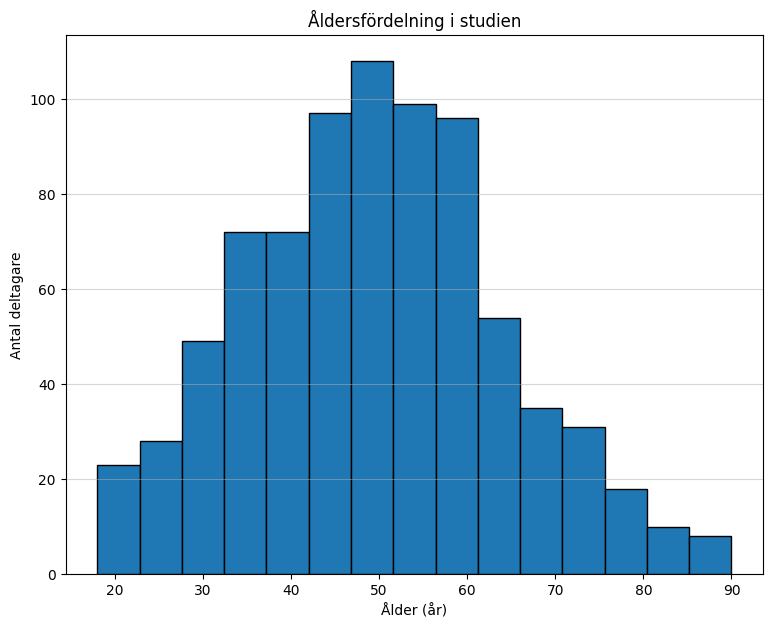

In [51]:
"""Skapar histogram över deltagarnas ålder"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.hist(df["age"], bins=15, edgecolor="black")
ax.set_title("Åldersfördelning i studien")
ax.set_xlabel("Ålder (år)")
ax.set_ylabel("Antal deltagare")
ax.grid(axis="y", alpha=0.5)

Diagrammet visar en någorlunda normalfördelning kring medelvärdet (50 år).

---

Att välja antalet bins är svårt. Även om det finns riktlinjer och formler för att räkna ut "korrekt" antal bins, är det ändå så att man i slutändan får utgå ifrån sin egen data och pröva sig fram. 

I vissa fall kan det vara aktuellt att ha olika stora bins, men vanligtvis använder man sig av bins som är lika stora. 

En mycket vanligt använd formel för att räkna ut antal bins är Square-root choice. Där antalet bins, k = roten ur antalet datapunkter. 

I mitt fall skulle k bli 28, men det tyckte jag fick histogrammet att se för rörigt ut. 

(Källa: https://en.wikipedia.org/wiki/Histogram)

Ålderspannet i studiens dataset är ungefär 70 år (90 - 18) och med 15 bins blir det ungefär 2 bins per 10 årspann. 

Det kändes lagom. 


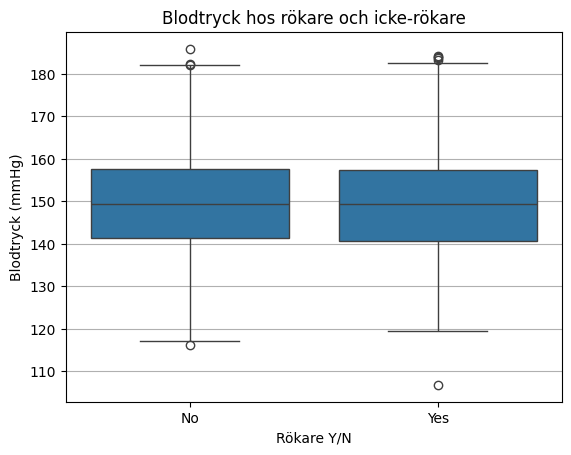

In [9]:
"""Boxplot, Blodtryck: Rökare vs Icke-rökare """

ax = sns.boxplot(df, x="smoker", y="systolic_bp")
ax.set(
    xlabel= "Rökare Y/N",
    ylabel= "Blodtryck (mmHg)",
    title= "Blodtryck hos rökare och icke-rökare"
)
ax.grid(True, axis="y")
plt.show()

Diagrammet visar att blodtrycket skiljer sig mycket lite mellan rökare och icke-rökare i den här studien.

---


matplotlib.pyplot.boxplot tar ett argument som är en array eller en sekvens av arrayer. 

Men det jag ville plotta var två kolumner ur en DataFrame, där den ena kolumnen dessutom skulle delas upp i "Ja" och "Nej". 

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

Att omvandla mitt format till det matplotlib "vill ha" kändes krånligt så jag började kolla efter ett enklare sätt. 

Jag sprang på den här online-guiden:

https://www.geeksforgeeks.org/python/how-to-create-boxplots-by-group-in-matplotlib/ 

Och upptäckte att seaborn gör det jag ville hur enkelt som helst. Med seaborn var det bara att ange vad som skulle vara på x-axeln och vad som skulle vara på y-axeln. 

I seaborn:s dokumentation finns det ett faq-avsnitt där jag hittade svar på hur man skriver titles och hur man får bort tråkig/onödig text som kom med (plt.show() löste det). 

Allt detta fungerade på samma sätt som med matplotlib så jag testade att lägga till grid på "det gamla sättet" och det fungerade ju! 

https://seaborn.pydata.org/faq.html 

Seaborn är ett bibliotek som används för att skapa statistiska diagram. Det bygger på Matplotlib och fungerar bra tillsammans med Pandas. 

Biblioteket gör det enklare att utforska och förstå data, då det automatiskt hanterar gruppering, färgkodning och beräkningar.

https://seaborn.pydata.org/tutorial/introduction.html

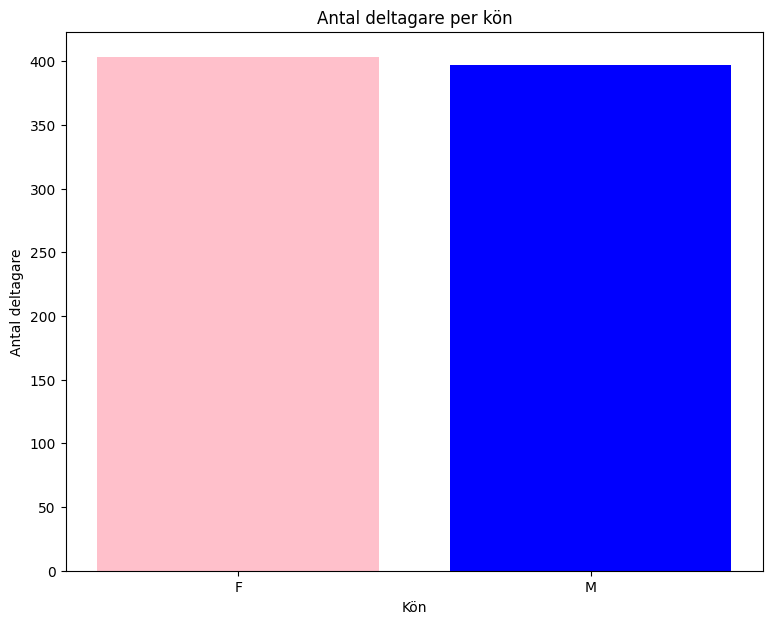

In [10]:
"""Stapeldiagram över antalet kvinnor och män"""

num_women_men = df["sex"].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_women_men.index, num_women_men.values, color=["pink", "blue"])
ax.set(
    title = "Antal deltagare per kön",
    xlabel = "Kön",
    ylabel = "Antal deltagare",
)
plt.show()

Historiskt har inte kvinnors hälsa studerats i samma utsträkning som mäns. Därför var det viktigt för mig att kolla hur fördelningen såg ut i den här studien. 

\#genderequality

\#women-supporting-women

\#womensempowerment


---

matplotlib.pyplot.bar tar två argument: x och height (y)

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

I mitt fall skulle x vara F eller M från kolumnen "sex" 

Och y skulle vara motsvarande antal. 

Att räkna antalet i en kolumn görs enkelt med .value_counts() och detta ger en Panda Series som ser ut så här:

Sex     Count
F       403
M       397

Jag sparade detta i en ny variabel, num_women_men, för att den skulle gå att använda.

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

.index hämtar etiketterna ur num_women_men.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.index.html

På liknande sätt hämtas värdena ur num_women_men h.j.a. .values. 

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.values.html

Dessa två delar blir mina x- och y-argument när jag sen plottar diagrammet. 

Jag gör på samma sätt med boxplottarna över andelen med sjukdom och andelen rökare.

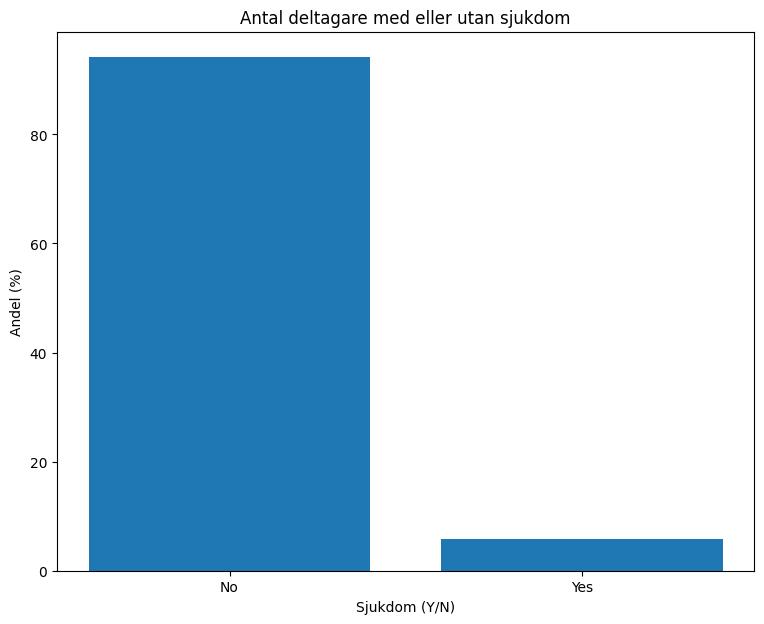

In [11]:
"""Stapeldiagram över andelen med sjukdom"""

num_disease = df["disease"].value_counts(normalize=True).round(4).rename(index={0: "No", 1: "Yes"}) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_disease.index, num_disease.values)
ax.set(
    title = "Antal deltagare med eller utan sjukdom",
    xlabel = "Sjukdom (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

De allra flesta deltagare är inte sjuka.

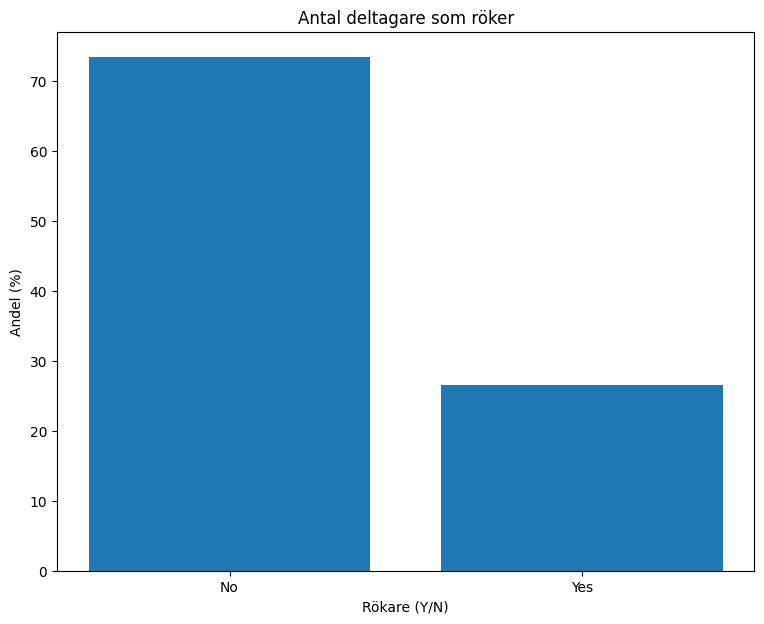

In [12]:
"""Stapeldiagram över andelen rökare"""

num_smoker = df["smoker"].value_counts(normalize=True).round(4) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_smoker.index, num_smoker.values)
ax.set(
    title = "Antal deltagare som röker",
    xlabel = "Rökare (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

Lite mer än en fjärdedel av deltagarna röker.

---


pandas.Series.value_counts har lite olika parametrar, däribland "normalize".

Om det inte är specificerat så är normalize=False, vilket ger antal. 

Men normalzie=True ger andelar (proportioner), vilket kändes som mer rimligt än det faktiska antalet. 

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

I kolumnen "disease" är datan 1 eller 0, inte Yes eller No, vilket gav ett knasigt resultat. 

Men då fick jag användning av .rename(index=) igen för att ändra 1 till Yes och 0 till No. 

Sedan visade det sig också att det är så lätt som att bara multiplicera allt med 100 för att få procent :) 

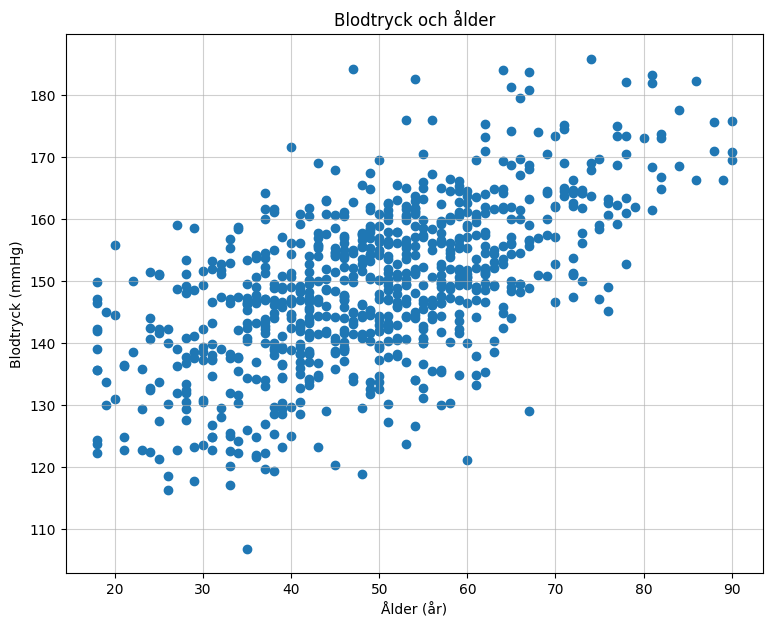

In [13]:
"""Scatterplot, blodtryck vs ålder"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df["age"], df["systolic_bp"])
ax.set(
    title = "Blodtryck och ålder",
    xlabel = "Ålder (år)",
    ylabel = "Blodtryck (mmHg)",
)
ax.grid(True, alpha=0.6)
plt.show()

Varje punkt representerar en individ i studien. 

Spridningsmönstret visar på ett positivt samband. 

Några punkter ligger utanför mönstret och kan betraktas som outliers. 

https://www.statology.org/which-variable-x-axis-y-axis/

## Simulering kopplad till caset

In [94]:
"""Beräkna andelen sjuka och andelen friska"""

disease_yes = df["disease"].mean()
disease_no = 1.0 - disease_yes

print(disease_yes)
print(disease_no)

0.05875
0.94125


In [ ]:
"""Simulera 1000 slumpade personer med samma sannolikhet för sjukdom"""

np.random.seed(42)

sim = np.random.choice([0, 1], size=1000, p=[disease_no, disease_yes])
sim_mean = sim.mean()

print(f"Den simulerade andelen med sjukdom är: {sim_mean}")
print(f"Den verkliga andelen är: {disease_yes}")
print(f"Skillnaden mellan de båda resultaten är: {disease_yes - sim_mean:.5f}")

Den simulerade andelen med sjukdom är: 0.056
Den verkliga andelen är: 0.05875
Skillnaden mellan de båda resultaten är: 0.00275


https://numpy.org/doc/2.3/reference/random/generated/numpy.random.choice.html#numpy-random-choice

## Konfidensintervall

### Normalapproximation

In [ ]:
systolic_bp_mean = df["systolic_bp"].mean()
systolic_bp_std = df["systolic_bp"].std()
systolic_bp_num = df["systolic_bp"].count()
se = systolic_bp_std / (np.sqrt(systolic_bp_num))
ci_min_normal = systolic_bp_mean - (1.96 * se)
ci_max_normal = systolic_bp_mean + (1.96 * se)

print(f"Medelvärdet på deltagarna i studien är: {systolic_bp_mean:.1f}")
print(f"95% konfidensintervall är: {ci_min_normal:.3f} - {ci_max_normal:.3f}")


Medelvärdet på deltagarna i studien är: 149.2
95% konfidensintervall är: 148.292 - 150.065


Formeln är medelvärde +/- (1.96 * se)

### Bootstrap

In [93]:
np.random.seed(666)

B = 5000
confidence = 0.95
x = df["systolic_bp"]
n = len(x)
boot_means = np.empty(B)

for b in range(B):
    boot_sample = np.random.choice(x, size=n, replace=True)
    boot_means[b] = np.mean(boot_sample)

ci_min_boot = np.percentile(boot_means, 2.5)
ci_max_boot = np.percentile(boot_means, 97.5)

print(f"Medelvärdet på deltagarna i studien är: {systolic_bp_mean:.1f}")
print(f"95% konfidensintervall är: {ci_min_boot:.3f} - {ci_max_boot:.3f}")


Medelvärdet på deltagarna i studien är: 149.2
95% konfidensintervall är: 148.310 - 150.069


https://www.youtube.com/watch?v=xjYEYBvPaSc&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=32&t=4s

## Hypotesprövning

### T-test

In [96]:
smoker_yes = df.loc[df.smoker == "Yes", "systolic_bp"].values
smoker_no = df.loc[df.smoker == "No", "systolic_bp"].values

t_stat, p_val = stats.ttest_ind(smoker_yes, smoker_no, equal_var=True)

t_stat_w, p_val_w = stats.ttest_ind(smoker_yes, smoker_no, equal_var=False)

print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

Standard t-test: t = 0.461, p = 0.6450
Welch t-test: t = 0.450, p = 0.6527


## Statistical Power